In [1]:
using_colab = False
if using_colab:
  !pip install torchinfo
  from google.colab import drive
  drive.mount('/content/drive')

In [2]:
from __future__ import annotations
from pathlib import Path
from typing import Optional, Tuple, Dict

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

from PIL import Image



import matplotlib.pyplot as plt

from torchinfo import summary

device = (
    torch.device("cuda") if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)

print("Using device:", device)

Using device: mps


## Model

In [4]:
def _safe_groups(c: int, max_groups: int) -> int:
    g = min(max_groups, c)
    while g > 1 and (c % g) != 0:
        g -= 1
    return max(g, 1)


class ResBlock(nn.Module):
    def __init__(self, c_in: int, c_out: int, k: int = 3, max_groups: int = 8):
        super().__init__()
        p = k // 2
        g = _safe_groups(c_out, max_groups)

        self.conv1 = nn.Conv2d(c_in, c_out, k, padding=p)
        self.gn1   = nn.GroupNorm(g, c_out)
        self.act1  = nn.SiLU(inplace=True)

        self.conv2 = nn.Conv2d(c_out, c_out, k, padding=p)
        self.gn2   = nn.GroupNorm(g, c_out)
        self.act2  = nn.SiLU(inplace=True)

        self.skip = nn.Identity() if c_in == c_out else nn.Conv2d(c_in, c_out, 1)

        # start near identity
        nn.init.zeros_(self.conv2.weight)
        if self.conv2.bias is not None:
            nn.init.zeros_(self.conv2.bias)

    def forward(self, x):
        h = self.act1(self.gn1(self.conv1(x)))
        h = self.gn2(self.conv2(h))
        return self.act2(h + self.skip(x))


class Downsample(nn.Module):
    def __init__(self, c_in: int, c_out: int, max_groups: int = 8):
        super().__init__()
        self.conv = nn.Conv2d(c_in, c_out, kernel_size=3, stride=2, padding=1)
        g = _safe_groups(c_out, max_groups)
        self.gn  = nn.GroupNorm(g, c_out)
        self.act = nn.SiLU(inplace=True)

    def forward(self, x):
        return self.act(self.gn(self.conv(x)))


class Upsample(nn.Module):
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.conv = nn.Conv2d(c_in, c_out, kernel_size=3, padding=1)

    def forward(self, x, size_hw=None):
        x = F.interpolate(x, scale_factor=2.0, mode="bilinear", align_corners=False)
        if size_hw is not None:
            x = F.interpolate(x, size=size_hw, mode="bilinear", align_corners=False)
        return self.conv(x)


class DeGhostUNet(nn.Module):
    """
    Residual U-Net with adjustable levels (downsample steps).

    levels=2 -> bottleneck at H/4
    levels=3 -> bottleneck at H/8 (more context; good for 256 crops)
    """
    def __init__(
        self,
        base: int = 64,
        in_ch: int = 1,
        out_ch: int = 1,
        levels: int = 3,
        max_groups: int = 8,
        mid_blocks: int = 2,
        pad_to_multiple: bool = False,
    ):
        super().__init__()
        assert levels >= 1
        self.levels = levels
        self.pad_to_multiple = pad_to_multiple

        # channel sizes per level: [base, 2base, 4base, ...]
        ch = [base * (2 ** i) for i in range(levels)]

        # Encoder: ResBlock at each level + Downsample between levels
        self.enc_blocks = nn.ModuleList()
        self.downs = nn.ModuleList()

        self.enc_blocks.append(ResBlock(in_ch, ch[0], max_groups=max_groups))
        for i in range(1, levels):
            self.downs.append(Downsample(ch[i - 1], ch[i], max_groups=max_groups))
            self.enc_blocks.append(ResBlock(ch[i], ch[i], max_groups=max_groups))

        # Bottleneck
        mid = []
        for _ in range(mid_blocks):
            mid.append(ResBlock(ch[-1], ch[-1], max_groups=max_groups))
        self.mid = nn.Sequential(*mid)

        # Decoder: Upsample + ResBlock with skip concat
        self.ups = nn.ModuleList()
        self.dec_blocks = nn.ModuleList()

        for i in reversed(range(levels - 1)):
            self.ups.append(Upsample(ch[i + 1], ch[i]))
            self.dec_blocks.append(ResBlock(ch[i] + ch[i], ch[i], max_groups=max_groups))

        self.out = nn.Conv2d(ch[0], out_ch, kernel_size=1)

    def _pad_to(self, x, mult: int):
        B, C, H, W = x.shape
        H2 = ((H + mult - 1) // mult) * mult
        W2 = ((W + mult - 1) // mult) * mult
        pad_h = H2 - H
        pad_w = W2 - W
        x = F.pad(x, (0, pad_w, 0, pad_h), mode="reflect")
        return x, (H, W)

    def forward(self, ghost: torch.Tensor) -> torch.Tensor:
        orig_hw = None
        if self.pad_to_multiple:
            mult = 2 ** self.levels
            ghost, orig_hw = self._pad_to(ghost, mult)

        skips = []

        # level 0
        x = self.enc_blocks[0](ghost)
        skips.append(x)

        # levels 1..L-1
        for i in range(1, self.levels):
            x = self.downs[i - 1](x)
            x = self.enc_blocks[i](x)
            skips.append(x)

        # bottleneck
        x = self.mid(x)

        # decode (levels-1 up steps)
        for k in range(self.levels - 1):
            skip = skips[-2 - k]  # corresponding encoder skip
            x = self.ups[k](x, size_hw=skip.shape[-2:])
            x = self.dec_blocks[k](torch.cat([x, skip], dim=1))

        residual = self.out(x)

        if orig_hw is not None:
            H, W = orig_hw
            residual = residual[..., :H, :W]

        return residual

In [5]:
# --- Model ---
model = DeGhostUNet(base=64)
checkpoint = torch.load("deghost_cnn_lvl-4.pt", map_location=device)

model.load_state_dict(checkpoint["model"])
model.to(device)
model.eval()

print("Checkpoint loaded.")
summary(model,input_size=(1,1,256,256))

Checkpoint loaded.


Layer (type:depth-idx)                   Output Shape              Param #
DeGhostUNet                              [1, 1, 256, 256]          --
├─ModuleList: 1-5                        --                        (recursive)
│    └─ResBlock: 2-1                     [1, 64, 256, 256]         --
│    │    └─Conv2d: 3-1                  [1, 64, 256, 256]         640
│    │    └─GroupNorm: 3-2               [1, 64, 256, 256]         128
│    │    └─SiLU: 3-3                    [1, 64, 256, 256]         --
│    │    └─Conv2d: 3-4                  [1, 64, 256, 256]         36,928
│    │    └─GroupNorm: 3-5               [1, 64, 256, 256]         128
│    │    └─Conv2d: 3-6                  [1, 64, 256, 256]         128
│    │    └─SiLU: 3-7                    [1, 64, 256, 256]         --
├─ModuleList: 1-4                        --                        (recursive)
│    └─Downsample: 2-2                   [1, 128, 128, 128]        --
│    │    └─Conv2d: 3-8                  [1, 128, 128, 128]

Text(0.5, 1.0, 'Crop with ghosting')

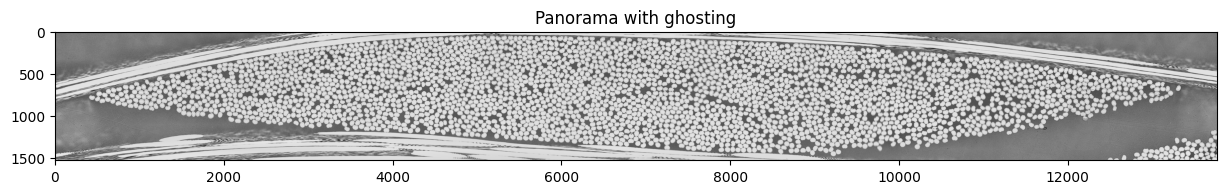

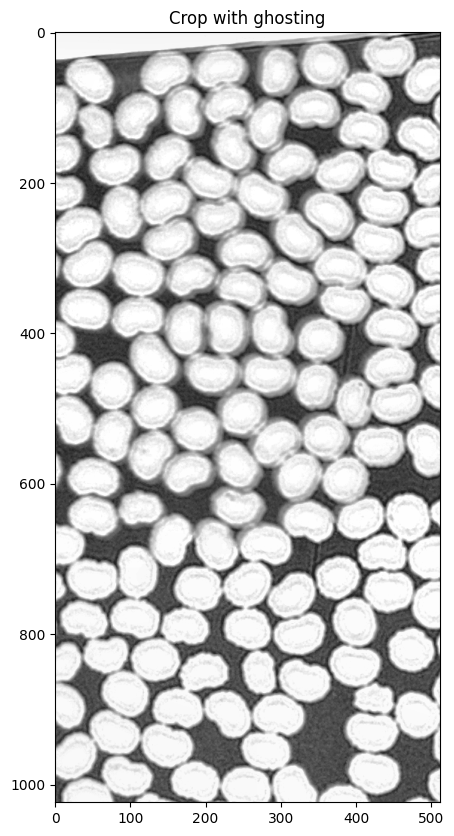

In [6]:
file_path  = Path("../../data/promotion/245_004.adj.tif")
# --- Load image ---
image_np = np.array(Image.open(file_path).convert("L"))

plt.figure(figsize=(15, 5))
plt.imshow(image_np, cmap="gray")
plt.title("Panorama with ghosting")

x0 = 3750
y0 = 80

w, h = 512, 1024


crop = image_np[y0:y0+h, x0:x0+w]
plt.figure(figsize=(10, 10))
plt.imshow(crop, cmap="gray")
plt.title("Crop with ghosting")



In [7]:
def extract_patches_from_crop(crop: np.ndarray, patch_size: int = 256, stride: int = 64):
    """
    Sliding-window patch extractor for a crop.

    Parameters
    ----------
    crop : np.ndarray
        2D image crop (H, W) (grayscale).
    patch_size : int
        Patch size (default 128).
    stride : int
        Stride (default 64).

    Returns
    -------
    patches : np.ndarray
        (N, patch_size, patch_size) float/uint array (same dtype as crop).
    coords : list[tuple[int,int]]
        List of (y, x) top-left coordinates in crop coordinates.
    """
    if crop.ndim != 2:
        raise ValueError(f"Expected 2D crop (H,W), got {crop.shape}")

    H, W = crop.shape
    patches, coords = [], []

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            patches.append(crop[y:y+patch_size, x:x+patch_size])
            coords.append((y, x))

    patches = np.stack(patches, axis=0) if patches else np.empty((0, patch_size, patch_size), dtype=crop.dtype)
    return patches, coords

def show_patch_grid(crop: np.ndarray, coords, patch_size: int = 128, stride: int = 64):
    """Visualize patch grid overlay on the crop."""
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(crop, cmap="gray")
    ax.set_title(f"Patch grid: size={patch_size}, stride={stride} (N={len(coords)})")

    for (y, x) in coords:
        rect = plt.Rectangle((x, y), patch_size, patch_size, edgecolor="red", facecolor="none", linewidth=0.6)
        ax.add_patch(rect)

    ax.axis("off")
    plt.show()

patches: (65, 256, 256) num coords: 65


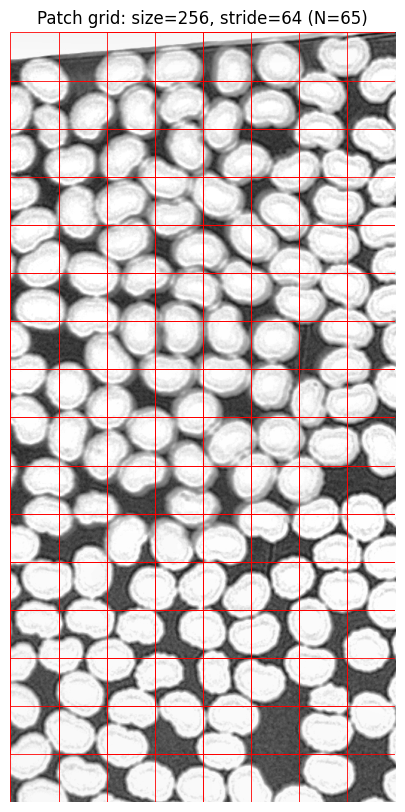

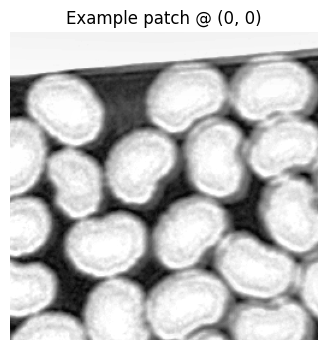

In [8]:
# --- Usage ---
patches, coords = extract_patches_from_crop(crop, patch_size=256, stride=64)
print("patches:", patches.shape, "num coords:", len(coords))

show_patch_grid(crop, coords, patch_size=256, stride=64)

# show one example patch
if len(patches) > 0:
    plt.figure(figsize=(4,4))
    plt.imshow(patches[0], cmap="gray")
    plt.title(f"Example patch @ {coords[0]}")
    plt.axis("off")
    plt.show()

In [9]:
def predict_clean_on_patches(
    patches: np.ndarray,                 # (N, H, W)
    model: torch.nn.Module,
    device: torch.device,
    batch_size: int = 32,
    downscale_factor: int = 2,
    normalize_uint8: bool = True,
    return_residual: bool = False,
    upsample_mode: str = "bilinear",     # "bilinear" (nice) or "nearest" (fast)
):
    """
    Runs deghost model on patches.
    Model is trained on downscaled inputs, so we:
      1) normalize + (B,1,H,W)
      2) downscale -> (B,1,H/d,W/d)
      3) predict residual at low-res
      4) pred_clean_low = x_low + pred_res_low
      5) upscale pred_clean_low back to (H,W)

    Returns:
      pred_clean_full: (N, H, W) float32 in [0,1]
      (optional) pred_res_full: (N, H, W) float32 (upsampled residual)
    """
    if patches.ndim != 3:
        raise ValueError(f"Expected patches (N,H,W), got {patches.shape}")

    model.eval()
    preds_clean_full = []
    preds_res_full = [] if return_residual else None

    N, H, W = patches.shape
    if H % downscale_factor != 0 or W % downscale_factor != 0:
        raise ValueError(
            f"Patch size {H}x{W} not divisible by downscale_factor={downscale_factor}"
        )

    with torch.no_grad():
        for s in range(0, N, batch_size):
            batch = patches[s:s+batch_size]

            x = torch.from_numpy(batch).float()
            if normalize_uint8:
                x = x / 255.0
            x = x.clamp(0, 1).unsqueeze(1)  # (B,1,H,W)

            # downscale to model resolution
            if downscale_factor != 1:
                x_low = F.interpolate(x, scale_factor=1/downscale_factor, mode="area")
            else:
                x_low = x

            x_low = x_low.to(device, non_blocking=True)

            # predict residual at low-res
            pred_res_low = model(x_low)                         # (B,1,h,w)
            pred_clean_low = (x_low + pred_res_low).clamp(0, 1) # (B,1,h,w)

            # upscale back to original patch size
            if downscale_factor != 1:
                pred_clean_full_t = F.interpolate(
                    pred_clean_low, size=(H, W), mode=upsample_mode, align_corners=False
                )
                if return_residual:
                    pred_res_full_t = F.interpolate(
                        pred_res_low, size=(H, W), mode=upsample_mode, align_corners=False
                    )
            else:
                pred_clean_full_t = pred_clean_low
                if return_residual:
                    pred_res_full_t = pred_res_low

            preds_clean_full.append(pred_clean_full_t[:, 0].cpu().numpy().astype(np.float32))
            if return_residual:
                preds_res_full.append(pred_res_full_t[:, 0].cpu().numpy().astype(np.float32))

    pred_clean_full = np.concatenate(preds_clean_full, axis=0)  # (N,H,W)

    if return_residual:
        pred_res_full = np.concatenate(preds_res_full, axis=0)  # (N,H,W)
        return pred_clean_full, pred_res_full

    return pred_clean_full


In [10]:
pred_clean_patches = predict_clean_on_patches(
    patches,
    model=model.to(device),
    device=device,
    batch_size=64,
    downscale_factor=1,
    normalize_uint8=(patches.dtype == np.uint8),
)

print(pred_clean_patches.shape)

(65, 256, 256)


In [11]:
def stitch_patches_mean(
    pred_patches: np.ndarray,   # (N, ph, pw)
    coords,                     # list[(y,x)] in ORIGINAL crop coords
    crop_shape,                 # (H,W) ORIGINAL crop shape
    patch_size: int = 128,
    stride: int = 64,
    downscale_factor: int = 2,
):
    """
    Reassemble (overlapping) predicted patches back into a full image by averaging overlaps.

    coords are given for the ORIGINAL crop coordinates (before downscale).
    pred_patches are at downscaled resolution (ph=pw=patch_size//downscale_factor).

    Returns:
        recon: (H//downscale, W//downscale) float32
        weight: same shape, overlap counts
    """
    if pred_patches.ndim != 3:
        raise ValueError(f"Expected pred_patches (N,ph,pw), got {pred_patches.shape}")
    if len(coords) != pred_patches.shape[0]:
        raise ValueError("coords length must match number of patches")

    H, W = crop_shape
    Hd, Wd = H // downscale_factor, W // downscale_factor

    ph = patch_size // downscale_factor
    pw = patch_size // downscale_factor

    recon = np.zeros((Hd, Wd), dtype=np.float32)
    weight = np.zeros((Hd, Wd), dtype=np.float32)

    for k, (y, x) in enumerate(coords):
        yd = y // downscale_factor
        xd = x // downscale_factor
        recon[yd:yd+ph, xd:xd+pw] += pred_patches[k]
        weight[yd:yd+ph, xd:xd+pw] += 1.0

    recon = recon / np.maximum(weight, 1e-6)
    return recon, weight


Text(0.5, 1.0, 'Reconstructed Clean Image')

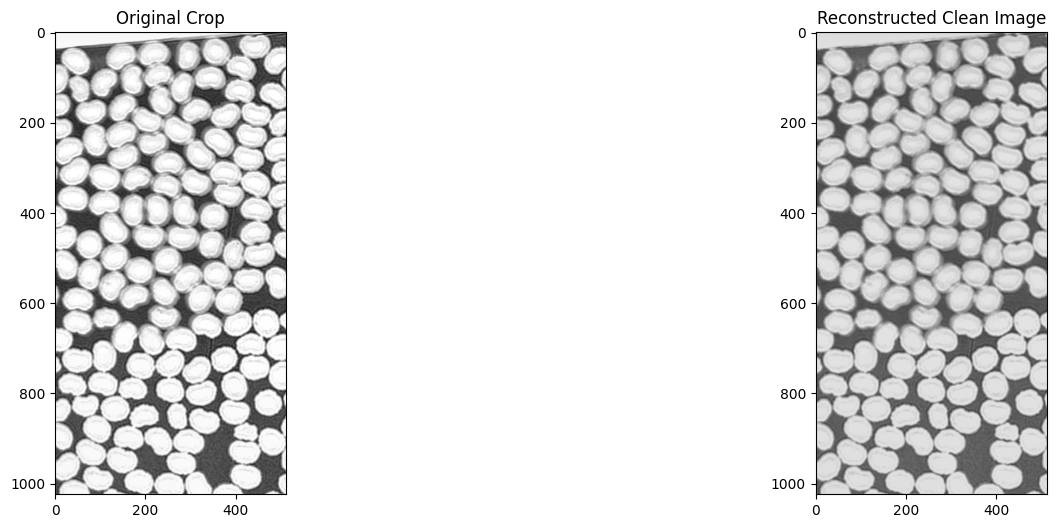

In [12]:
recon_clean, w = stitch_patches_mean(pred_clean_patches, coords, crop.shape, patch_size=256, stride=64, downscale_factor=1)


fig, axs = plt.subplots(1, 2, figsize=(18, 6))
axs[0].imshow(crop, cmap="gray")
axs[0].set_title("Original Crop")
axs[1].imshow(recon_clean, cmap="gray",vmin=0, vmax=1)
axs[1].set_title("Reconstructed Clean Image")